In [2]:
import torch
import mylib

from torch import nn

In [3]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(400, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

loss 0.474, train acc 0.820, est acc 0.815
41722.9 example/sec on cuda:0


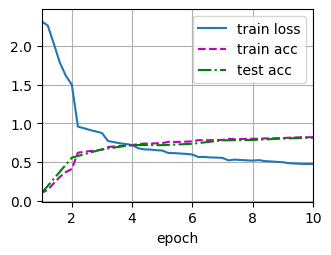

In [5]:
batch_size = 256
train_iter, test_iter = mylib.load_data_fashion_mnist(batch_size)

lr, num_epochs = 0.9, 10
mylib.train(net, train_iter, test_iter, num_epochs, lr, mylib.try_gpu())

In [ ]:
## 维数测试
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, "output shape:\t \t", X.shape)

Conv2d output shape:	 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 	 torch.Size([1, 400])
Linear output shape:	 	 torch.Size([1, 120])
Sigmoid output shape:	 	 torch.Size([1, 120])
Linear output shape:	 	 torch.Size([1, 84])
Sigmoid output shape:	 	 torch.Size([1, 84])
Linear output shape:	 	 torch.Size([1, 10])
